# Full Bayesian Operator Inference: Cubic Heat Equation

**Workflow:**
1. Generate training data (multiple ICs) and fit POD basis
2. Grid search for prior operator
3. Fit GP hyperparameters
4. Run Bayesian inference (SVI/MCMC)
5. Evaluate and visualize results (including test IC)

## 1. Setup and Configuration

In [111]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro

from core import (
    grid_search_prior_operator,
    fit_gp_hyperparameters_mle,
    build_bayesian_opinf_model,
    run_svi,
    run_mcmc,
    generate_rom_predictions,
    plot_gp_fit,
    run_diagnostics,
    save_paper_figure,
    DataScaler,
)
from config import (
    FullOrderModel, Basis,
    input_func_factory, input_parameters, test_parameters,
    time_domain, initial_conditions,
)
import step1_generate_data as step1

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

# Reproducibility
np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

In [112]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAHBN"
IVP_METHOD = "BDF"   # ODE solver for stability testing       # OpInf operator structure (with inputs)
NUM_MODES = 5            # POD modes to retain
NUM_TRAIN_ICS = 5         # Number of training ICs to use

# Time domain settings
TRAINING_SPAN = (0, 1.0)  # Subset of time_domain used for training
PREDICTION_SPAN = (0, 2.0) # Full time domain for ROM evaluation (includes extrapolation)

# Data generation settings
NUM_SAMPLES = 65          # Number of uniformly subsampled training snapshots per trajectory
NOISE_LEVEL = 0.02       # Noise as fraction of signal (0 = no noise)
NUM_EVAL_POINTS = 150    # Set to None to use the original training times (no densification)

# Data scaling
USE_SCALED_DATA = False   # Standardize POD coefficients for GP fitting

# Inference settings
RUN_SVI = True
RUN_MCMC = True           # More expensive, optional
USE_DETERMINISTIC_INIT_FOR_SVI = False  # Initialize MCMC from MAP estimate (requires RUN_SVI=False)
USE_SVI_FOR_MCMC_INIT = True  # Initialize MCMC from SVI result (requires RUN_SVI=True)
USE_SHIFTED_PRIOR_FOR_MCMC = True  # Rebuild model with prior shifted to SVI posterior for MCMC
GUIDE = numpyro.infer.autoguide.AutoDelta  # Guide for SVI; ignored if not using SVI
VERBOSE = True             # Show progress bars (set False for papermill runs)

# Hyperparameters
GAMMA = 1e0      # Operator prior variance
GAMMA2 = 1e0     # ODE constraint stiffness
GAMMA3 = 1e-1      # Operator prior variance for MCMC (if different from SVI)
GAMMA4 = 1e-1     # ODE constraint stiffness for MCMC (if different from SVI)

# Paper figure generation
SAVE_PAPER_FIGURES = False         # Set True to save publication figures
PAPER_SCENARIO = "dense_low"      # Scenario tag: dense_low, dense_high, sparse_medium, etc.
PAPER_FIGURES_DIR = "../../GP-Bayes-Refactor/figures/manu"

## 2. Generate Training Data

In [113]:
# Select training and test parameters
train_params = input_parameters[:NUM_TRAIN_ICS]
test_params = test_parameters

print(f"Training parameters: {train_params}")
print(f"Test parameters: {test_params}")

# Use same TrajectorySampler as GP-Bayes for identical data generation
NUM_REGRESSION_POINTS = 150
sampler = step1.TrajectorySampler(
    TRAINING_SPAN,
    NUM_SAMPLES,
    NOISE_LEVEL,
    NUM_REGRESSION_POINTS,
    synced=False,
)

(
    all_true_states,
    all_time_sampled,
    all_snapshots,
    all_training_inputs,
) = sampler.multisample(train_params, plot=False)

# Build the full prediction time domain
time_domain_full = time_domain[
    (time_domain >= PREDICTION_SPAN[0]) & (time_domain <= PREDICTION_SPAN[1])
]

# Use the first trajectory's sample times as the common reference
# (matches GP-Bayes which uses per-trajectory random times but
# the basis is fit on all trajectories together)

# Compute inputs on full domain for each IC
all_inputs_full = []
for params in train_params:
    ifunc = input_func_factory(params)
    all_inputs_full.append(ifunc(time_domain_full))

# Compute inputs at sampled times per trajectory
all_inputs = []
for i, params in enumerate(train_params):
    ifunc = input_func_factory(params)
    all_inputs.append(ifunc(all_time_sampled[i]))

# Stack all training data
snapshots_train = np.hstack(all_snapshots)
inputs_train = np.hstack(all_inputs)

print(f"\nTraining span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Noise level: {NOISE_LEVEL:.1%}")
print(f"Samples per trajectory: {NUM_SAMPLES}")
print(f"Full time domain points: {len(time_domain_full)}")
print(f"Training snapshots (noisy, subsampled): {snapshots_train.shape}")
print(f"Training inputs: {inputs_train.shape}")
print(f"Training time (IC 0): [{all_time_sampled[0][0]:.4f}, {all_time_sampled[0][-1]:.4f}]")


Training parameters: ((-2, 0), (-1, -2), (0, 1), (1, -1), (2, 2))
Test parameters: (1.5, 0.5)

Training span: [0, 1.0]
Prediction span: [0, 2.0]
Noise level: 2.0%
Samples per trajectory: 65
Full time domain points: 500
Training snapshots (noisy, subsampled): (500, 325)
Training inputs: (2, 325)
Training time (IC 0): [0.0000, 1.0000]


In [114]:
# Generate test trajectory via same sampler (consistent random state)
(
    snapshots_test,          # true states on full config.time_domain
    time_sampled_test,       # sampled times (not used further)
    snapshots_test_noisy,    # noisy test snapshots (not used further)
    inputs_test_train,       # test inputs at regression points (not used further)
) = sampler.sample(test_params)

test_input_func = input_func_factory(test_params)
inputs_test = test_input_func(time_domain_full)

print(f"Test snapshots: {snapshots_test.shape}")
print(f"Test time span: [{time_domain_full[0]:.4f}, {time_domain_full[-1]:.4f}]")


Test snapshots: (500, 500)
Test time span: [0.0000, 2.0000]


In [115]:
# Fit POD basis (with lifting: q, q^2)
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_train)

snapshots_compressed = basis.compress(snapshots_train)
snapshots_test_compressed = basis.compress(snapshots_test)

# Also compress per-trajectory for GP fitting (each has its own sample times)
all_snapshots_comp_raw = [basis.compress(s) for s in all_snapshots]
# Compress full truth for each training traj (on full time domain)
all_true_compressed = [basis.compress(s) for s in all_true_states]
# Compress test truth
test_compressed = basis.compress(snapshots_test)

print(f"Compressed shape: {snapshots_compressed.shape}")
print(f"Test compressed shape: {snapshots_test_compressed.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")


Compressed shape: (5, 325)
Test compressed shape: (5, 500)
Cumulative energy: 98.6886%


In [116]:
# For grid search and GP fitting, use first trajectory only.
snapshots_first = all_snapshots[0]
snapshots_comp_first = all_snapshots_comp_raw[0]
inputs_first = np.array(all_inputs[0])

print(f"Training samples per traj: {NUM_SAMPLES}")
print(f"Total training samples: {snapshots_compressed.shape[1]}")
print(f"First traj sample times: [{all_time_sampled[0][0]:.4f}, {all_time_sampled[0][-1]:.4f}]")

# Set up evaluation time domains for plotting
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)

print(f"Eval training domain: [{time_domain_eval_training[0]:.4f}, {time_domain_eval_training[-1]:.4f}] ({len(time_domain_eval_training)} pts)")
print(f"Eval prediction domain: [{time_domain_eval_prediction[0]:.4f}, {time_domain_eval_prediction[-1]:.4f}] ({len(time_domain_eval_prediction)} pts)")


Training samples per traj: 65
Total training samples: 325
First traj sample times: [0.0000, 1.0000]
Eval training domain: [0.0000, 1.0000] (150 pts)
Eval prediction domain: [0.0000, 2.0000] (150 pts)


## 3a. Data Scaling (Optional)

When `USE_SCALED_DATA=True`, each POD mode is standardized to zero mean and unit variance before GP fitting. This improves GP hyperparameter learning and numerical conditioning.

The scaling is handled consistently:
1. GPs are fitted on scaled data
2. In the Bayesian model: latent states live in scaled space → transformed to original for operator dynamics → derivatives scaled back for comparison with GP derivatives
3. Posterior predictions are inverse-transformed back to original space

In [117]:
# Optionally scale data for GP fitting
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_first)
    training_data = data_scaler.transform(snapshots_comp_first)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_first
    print("Scaling disabled: using raw POD coefficients")


Scaling disabled: using raw POD coefficients


## 3. Grid Search for Prior Operator

In [118]:
# Find best deterministic operator via regularization grid search
# Use first training trajectory for initial search
first_input_func = input_func_factory(train_params[0])

result = grid_search_prior_operator(
    basis=basis,
    time_domain_sampled=all_time_sampled[0],
    snapshots_sampled=snapshots_first,
    snapshots_compressed=snapshots_comp_first,
    operators=OPERATORS,
    inputs=inputs_first,
    input_func=first_input_func,
    verbose=VERBOSE,
    ivp_method=IVP_METHOD,
)

prior_operator = result.operator
rom = result.rom
print(f"\nPrior operator shape: {prior_operator.shape}")


Grid search: testing 81 regularization values...
  reg=1.0e-16: UNSTABLE
  reg=1.8e-16: UNSTABLE
  reg=3.2e-16: UNSTABLE
  reg=5.6e-16: UNSTABLE
  reg=1.0e-15: UNSTABLE
  reg=1.8e-15: UNSTABLE
  reg=3.2e-15: UNSTABLE
  reg=5.6e-15: UNSTABLE
  reg=1.0e-14: UNSTABLE
  reg=1.8e-14: UNSTABLE
  reg=3.2e-14: UNSTABLE
  reg=5.6e-14: UNSTABLE
  reg=1.0e-13: UNSTABLE
  reg=1.8e-13: UNSTABLE
  reg=3.2e-13: UNSTABLE
  reg=5.6e-13: UNSTABLE
  reg=1.0e-12: UNSTABLE
  reg=1.8e-12: UNSTABLE
  reg=3.2e-12: UNSTABLE
  reg=5.6e-12: UNSTABLE
  reg=1.0e-11: UNSTABLE
  reg=1.8e-11: UNSTABLE
  reg=3.2e-11: UNSTABLE
  reg=5.6e-11: UNSTABLE
  reg=1.0e-10: UNSTABLE
  reg=1.8e-10: UNSTABLE
  reg=3.2e-10: UNSTABLE
  reg=5.6e-10: UNSTABLE
  reg=1.0e-09: UNSTABLE
  reg=1.8e-09: UNSTABLE
  reg=3.2e-09: UNSTABLE
  reg=5.6e-09: UNSTABLE
  reg=1.0e-08: UNSTABLE
  reg=1.8e-08: UNSTABLE
  reg=3.2e-08: UNSTABLE
  reg=5.6e-08: UNSTABLE
  reg=1.0e-07: UNSTABLE
  reg=1.8e-07: UNSTABLE
  reg=3.2e-07: UNSTABLE
  reg=5.6e-07: 

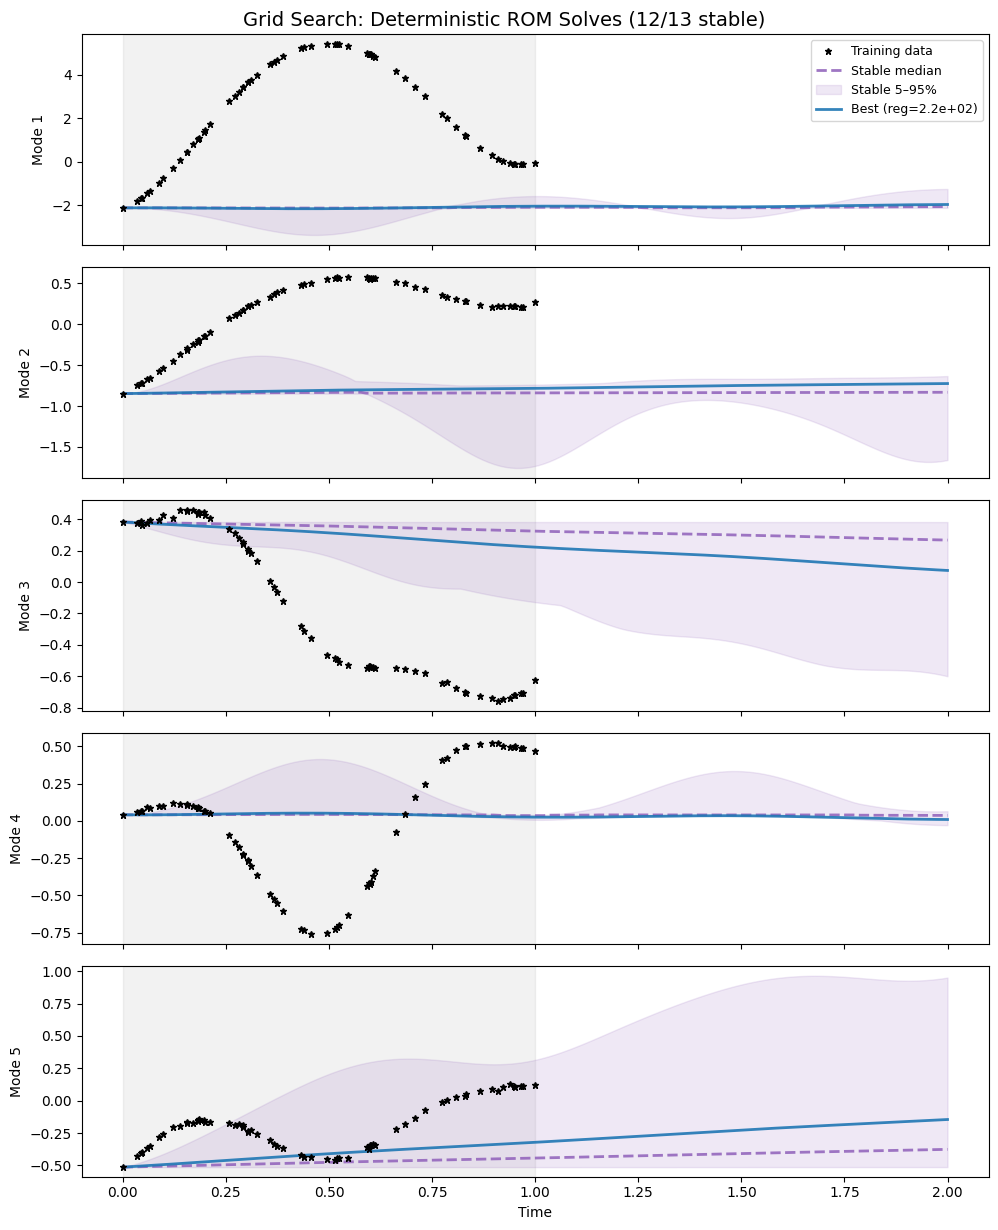

In [119]:
# Plot all stable deterministic ROM solves from grid search
from heat_plotter import plot_heat_grid_search

first_input_func = input_func_factory(train_params[0])

fig, axes = plot_heat_grid_search(
    grid_search_result=result,
    snapshots_compressed=snapshots_comp_first,
    time_sampled=all_time_sampled[0],
    time_eval_training=time_domain_eval_training,
    time_eval_prediction=time_domain_eval_prediction,
    num_modes=NUM_MODES,
    input_func=first_input_func,
    training_span=TRAINING_SPAN,
)
plt.show()


## 4. Fit GP Hyperparameters

In [120]:
# Start timing the algorithm
import time
start_time = time.time()
total_plot_time = 0

# Fit GP for each mode via MLE — per trajectory
# Each IC has its own sample times (from TrajectorySampler).

all_Ls, all_Vs, all_Ns, all_gp_models = [], [], [], []
all_snapshots_comp = []

for ic_idx in range(NUM_TRAIN_ICS):
    snap_ic = all_snapshots_comp_raw[ic_idx]
    data_ic = data_scaler.transform(snap_ic) if USE_SCALED_DATA else snap_ic
    all_snapshots_comp.append(data_ic)

    print(f"\n--- IC {ic_idx+1} ({train_params[ic_idx]}) ---")
    Ls_ic, Vs_ic, Ns_ic, gps_ic = fit_gp_hyperparameters_mle(
        time_domain=all_time_sampled[ic_idx],
        snapshots=data_ic,
        verbose=VERBOSE
    )
    all_Ls.append(Ls_ic)
    all_Vs.append(Vs_ic)
    all_Ns.append(Ns_ic)
    all_gp_models.append(gps_ic)

# Keep first-IC references for backward compat
Ls, Vs, Ns, gp_models = all_Ls[0], all_Vs[0], all_Ns[0], all_gp_models[0]
print(f"\nFitted GPs for {NUM_TRAIN_ICS} trajectories × {NUM_MODES} modes")



--- IC 1 ((-2, 0)) ---
Fitting GP hyperparameters via MLE...
  L=0.2987, V=16.4411, N=0.000096
  Mode 0: L=0.2987, V=16.4411, N=0.000096
  L=0.2967, V=0.3829, N=0.000076
  Mode 1: L=0.2967, V=0.3829, N=0.000076
  L=0.2324, V=0.3511, N=0.000061
  Mode 2: L=0.2324, V=0.3511, N=0.000061
  L=0.2214, V=0.2493, N=0.000027
  Mode 3: L=0.2214, V=0.2493, N=0.000027
  L=0.2528, V=0.1943, N=0.000101
  Mode 4: L=0.2528, V=0.1943, N=0.000101

--- IC 2 ((-1, -2)) ---
Fitting GP hyperparameters via MLE...
  L=0.2499, V=7.3484, N=0.000192
  Mode 0: L=0.2499, V=7.3484, N=0.000192
  L=0.1639, V=5.6611, N=0.000079
  Mode 1: L=0.1639, V=5.6611, N=0.000079
  L=0.2712, V=0.1005, N=0.000143
  Mode 2: L=0.2712, V=0.1005, N=0.000143
  L=0.1688, V=0.0438, N=0.000023
  Mode 3: L=0.1688, V=0.0438, N=0.000023
  L=0.2058, V=0.1628, N=0.000098
  Mode 4: L=0.2058, V=0.1628, N=0.000098

--- IC 3 ((0, 1)) ---
Fitting GP hyperparameters via MLE...
  L=0.2701, V=4.0298, N=0.000174
  Mode 0: L=0.2701, V=4.0298, N=0.00017

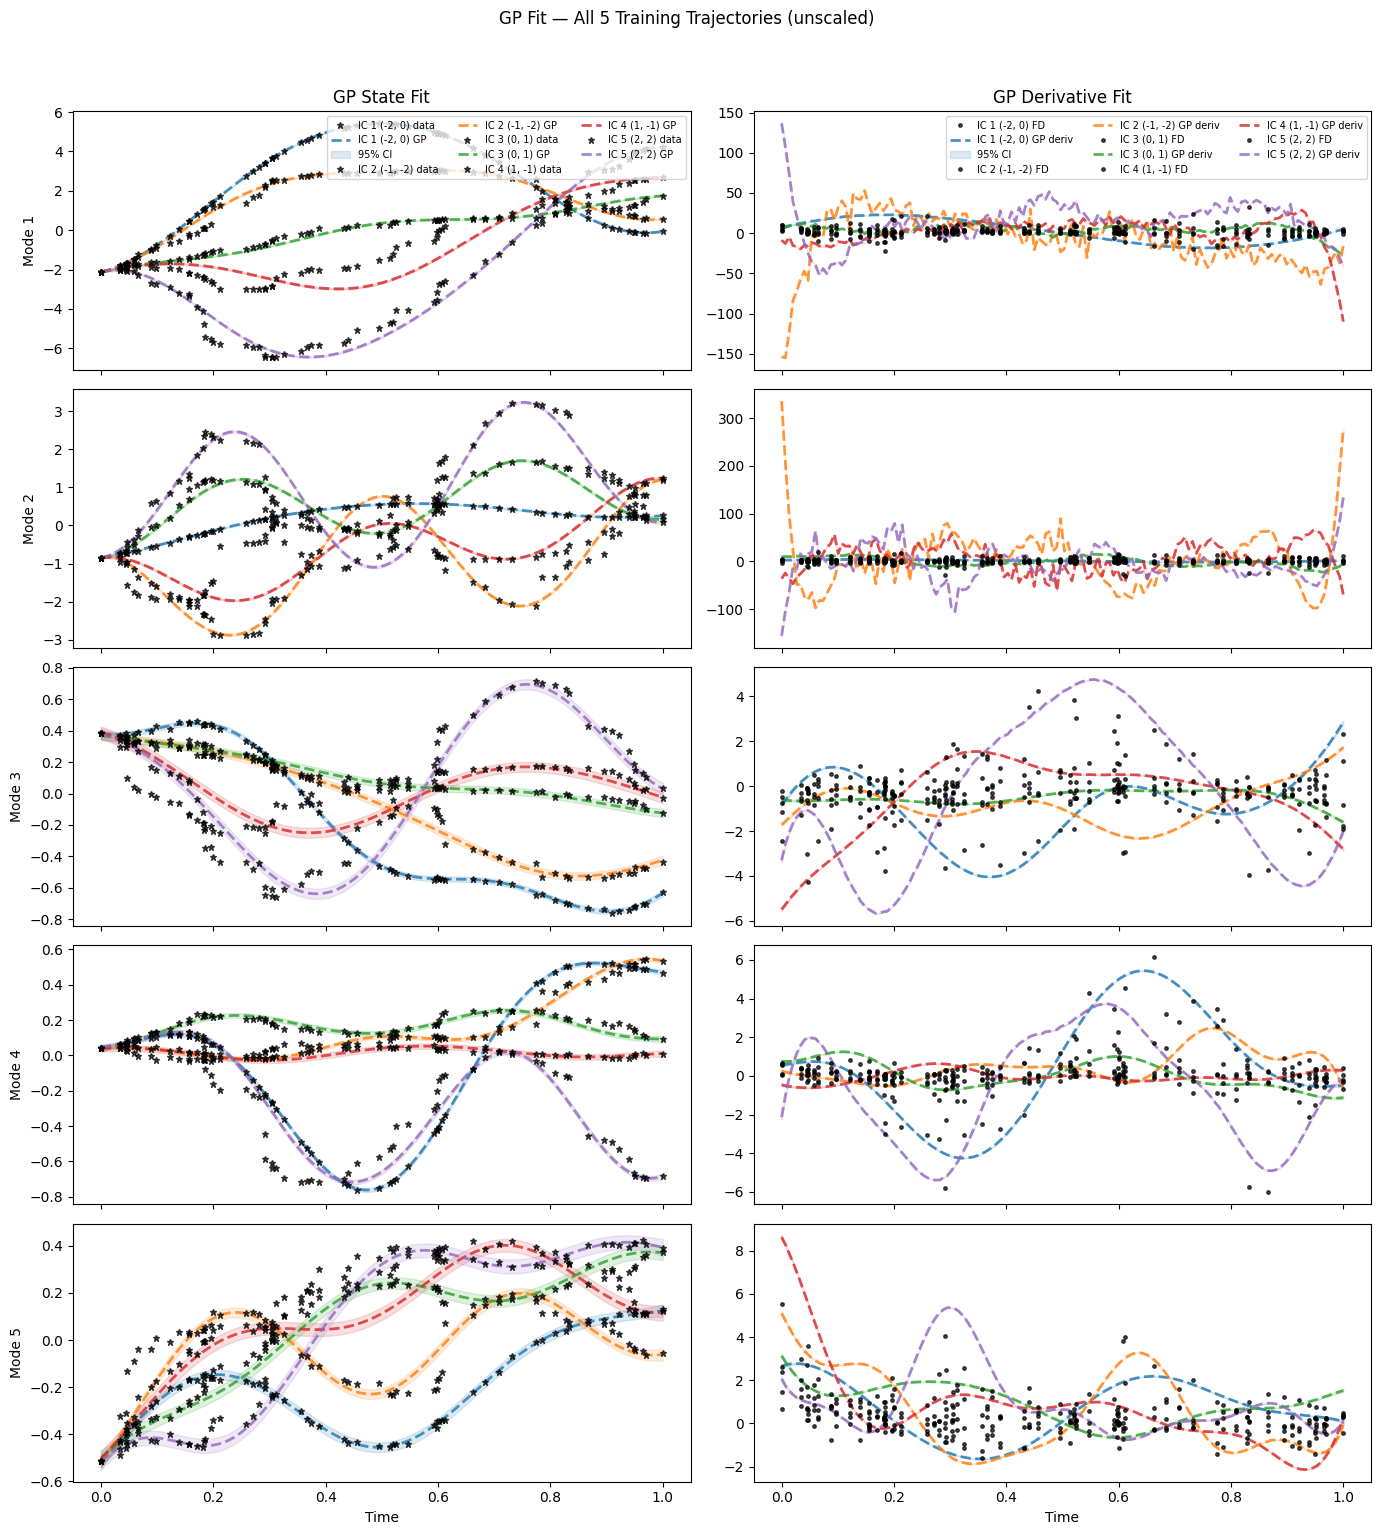

In [121]:
_plot_t0 = time.time()
# Visualize GP fit quality for ALL training trajectories (grid layout)
gp_result = plot_gp_fit(
    gp_models=gp_models,
    snapshots_compressed=all_snapshots_comp[0],
    time_sampled=all_time_sampled[0],
    time_eval=time_domain_eval_training,
    lengthscales=Ls,
    variances=Vs,
    plot_derivatives=True,
    # Multi-trajectory grid
    all_snapshots_compressed=all_snapshots_comp,
    all_gp_models=all_gp_models,
    all_lengthscales=all_Ls,
    all_variances=all_Vs,
    all_time_sampled=all_time_sampled,
    trajectory_labels=[f"IC {i+1} {train_params[i]}" for i in range(NUM_TRAIN_ICS)],
)
plt.show()
total_plot_time += time.time() - _plot_t0


## 5. Bayesian Inference

In [122]:
# Build evaluation time grid (densified via GP if NUM_EVAL_POINTS is set)
if NUM_EVAL_POINTS is not None:
    time_eval = np.linspace(all_time_sampled[0][0], all_time_sampled[0][-1], NUM_EVAL_POINTS)
    print(f"GP densification: evaluating ODE constraints at {NUM_EVAL_POINTS} points "
          f"(vs {NUM_SAMPLES} training samples)")
else:
    time_eval = all_time_sampled[0]
    print(f"No densification: evaluating at {NUM_SAMPLES} training times")

# Precompute GP mean predictions at evaluation points — per IC
all_Xs_means = []
all_inputs_eval = []
for ic_idx in range(NUM_TRAIN_ICS):
    Xs_means_ic = np.array([
        all_gp_models[ic_idx][i].predict(time_eval[:, None], return_std=False)
        for i in range(NUM_MODES)
    ])
    all_Xs_means.append(Xs_means_ic)
    
    ic_input_func = input_func_factory(train_params[ic_idx])
    all_inputs_eval.append(np.array(ic_input_func(time_eval)))

# Keep first-IC references for backward compat
Xs_means = all_Xs_means[0]
inputs_eval = all_inputs_eval[0]
first_input_func = input_func_factory(train_params[0])

print(f"Prepared GP predictions for {NUM_TRAIN_ICS} trajectories")
print(f"  Xs_means per IC shape: {all_Xs_means[0].shape}")
print(f"  inputs_eval per IC shape: {all_inputs_eval[0].shape}")

# Build Bayesian model with multi-IC ODE constraints
bayesian_opinf_model = build_bayesian_opinf_model(
    prior_operator=prior_operator if not USE_DETERMINISTIC_INIT_FOR_SVI else jnp.zeros_like(prior_operator),
    rom=rom,
    Ls_means=all_Ls,
    Vs_means=all_Vs,
    time_domain_sampled=all_time_sampled,
    snapshots=all_snapshots_comp,
    Xs_means=all_Xs_means,
    Ns_means=all_Ns,
    inputs_eval=all_inputs_eval,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
)
print(f"Bayesian model built with {NUM_TRAIN_ICS} IC(s) × {NUM_MODES} mode(s) "
      f"= {NUM_TRAIN_ICS * NUM_MODES} ODE constraint terms")


GP densification: evaluating ODE constraints at 150 points (vs 65 training samples)
Prepared GP predictions for 5 trajectories
  Xs_means per IC shape: (5, 150)
  inputs_eval per IC shape: (2, 150)
Bayesian model built with 5 IC(s) × 5 mode(s) = 25 ODE constraint terms


Running SVI (gamma=1.0, gamma2=1.0)...


100%|██████████| 5000/5000 [00:17<00:00, 286.67it/s, init loss: 130682.9531, avg. loss [4751-5000]: 3772.8306]


✅ SVI complete! Final loss: 3770.8816
   Sample keys: ['O', 'X0_0', 'X0_1', 'X0_2', 'X0_3', 'X0_4', 'X1_0', 'X1_1', 'X1_2', 'X1_3', 'X1_4', 'X2_0', 'X2_1', 'X2_2', 'X2_3', 'X2_4', 'X3_0', 'X3_1', 'X3_2', 'X3_3', 'X3_4', 'X4_0', 'X4_1', 'X4_2', 'X4_3', 'X4_4']
SVI operator extracted from key 'O', shape: (5, 33)


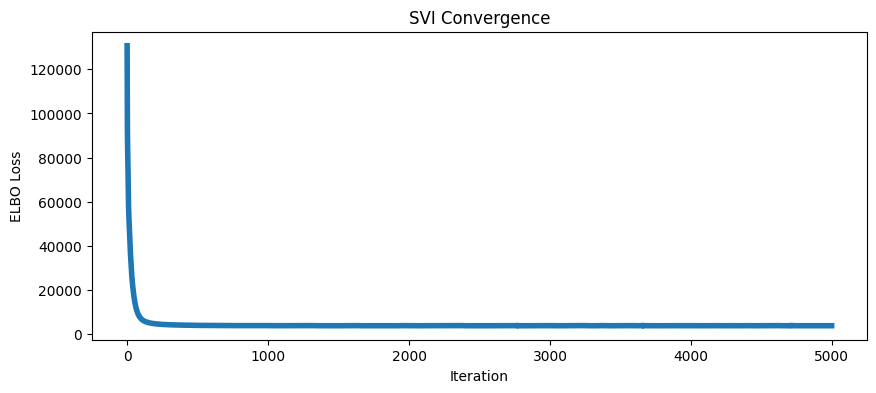

In [123]:
# Run SVI
if RUN_SVI:
    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=5000,
        learning_rate=1e-1,
        verbose=VERBOSE,
        guide=GUIDE
    )
    samples = svi_result.samples
    
    # Extract operator for potential MCMC initialization
    # AutoDelta stores as 'O_auto_loc', MCMC stores as 'O'
    O_key = next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        # Get point estimate (mean over samples or first sample)
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")
    
    # Plot loss
    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses, lw=4)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

### 5a. SVI Results

In [124]:
import importlib, heat_plotter
importlib.reload(heat_plotter)
from heat_plotter import HeatPlotter, compute_trajectory_errors, plot_operator_comparison

def _build_trajectories():
    """Build trajectory dicts for all training ICs + test IC."""
    trajs = []
    for ic_idx in range(NUM_TRAIN_ICS):
        s, e = ic_idx * NUM_SAMPLES, (ic_idx + 1) * NUM_SAMPLES
        trajs.append({
            'q0': all_snapshots_comp_raw[ic_idx][:, 0],
            'input_func': input_func_factory(train_params[ic_idx]),
            'snapshots': all_snapshots_comp_raw[ic_idx],
            'time_snapshots': all_time_sampled[ic_idx],
            'true_compressed': all_true_compressed[ic_idx],
            'time_true': time_domain_full,
            'label': f'Train {ic_idx+1} {train_params[ic_idx]}',
        })
    trajs.append({
        'q0': snapshots_test_compressed[:, 0],
        'input_func': input_func_factory(test_params),
        'snapshots': None,
        'time_snapshots': None,
        'true_compressed': snapshots_test_compressed,
        'time_true': time_domain_full,
        'label': f'Test {test_params}',
    })
    return trajs

def _evaluate_and_plot(stage_samples, stage_name):
    """Generate predictions, heatmap, and multi-trajectory plot for a given stage."""
    Os_stage, Xs_stage, rom_solves_stage = generate_rom_predictions(
        samples=stage_samples, rom=rom,
        snapshots_compressed=snapshots_comp_first,
        time_eval=time_domain_eval_prediction,
        num_modes=NUM_MODES, num_pulls=200,
        input_func=first_input_func,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
    ,
        ivp_method=IVP_METHOD,
)
    print(f"[{stage_name}] Operator samples: {len(Os_stage)}, "
          f"Stable solves (1st IC): {len(rom_solves_stage)}")

    # Operator heatmap comparison
    O_mean_stage = Os_stage.mean(axis=0)
    fig, _ = plot_operator_comparison(
        prior_operator, O_mean_stage,
        title=f'Operator Comparison: Deterministic vs {stage_name} Mean',
    )
    plt.show()

    # Multi-trajectory ROM plot
    plotter_stage = HeatPlotter(
        numPODmodes=NUM_MODES,
        time_domain_training=all_time_sampled[0],
        time_domain_prediction=time_domain_full,
        time_domain_eval_training=time_domain_eval_training,
        time_domain_eval_prediction=time_domain_eval_prediction,
        snapshots_training=snapshots_comp_first,
        snapshots_prediction=snapshots_comp_first,
    )
    trajs = _build_trajectories()
    fig_rom, axes, all_solves = plotter_stage.multi_trajectory_plot(
        operator_samples=Os_stage, rom=rom,
        trajectories=trajs, time_eval=time_domain_eval_prediction,
        max_num_samples=200, training_span=TRAINING_SPAN,
    )
    fig_rom.suptitle(f'ROM Predictions ({stage_name}): All Trajectories', fontsize=14, y=1.05)
    plt.show()

    # Errors
    all_errs = {}
    for i, (traj, solves_i) in enumerate(zip(trajs, all_solves)):
        lbl = traj.get('label', f'Traj {i+1}')
        if len(solves_i) > 0 and traj.get('true_compressed') is not None:
            errs = compute_trajectory_errors(
                solves_i, traj['true_compressed'],
                time_domain_eval_prediction, traj['time_true'], NUM_MODES,
            )
            all_errs[lbl] = errs
            print(f"  {lbl}: mean err = {np.mean(errs):.4%}, stable = {len(solves_i)}")
        else:
            print(f"  {lbl}: No stable ROM solutions")

    return Os_stage, all_solves, all_errs, fig_rom

[SVI] Operator samples: 200, Stable solves (1st IC): 200


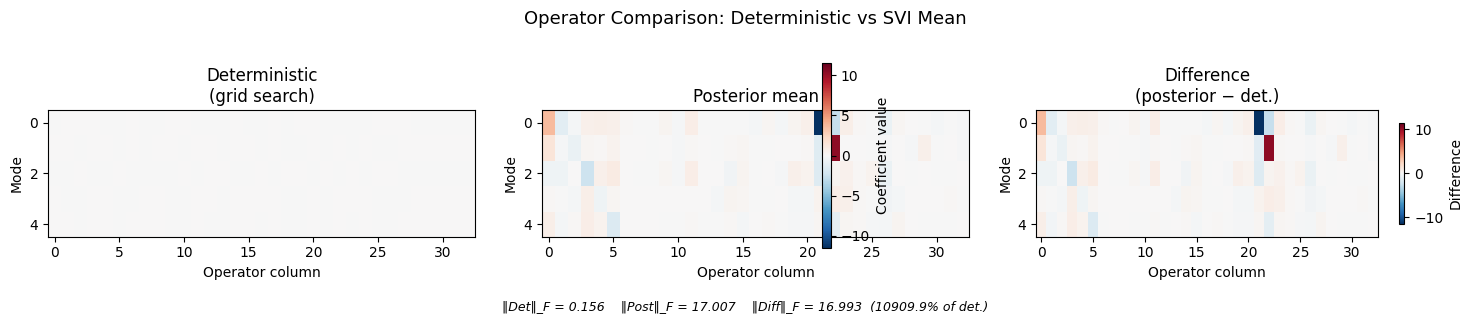

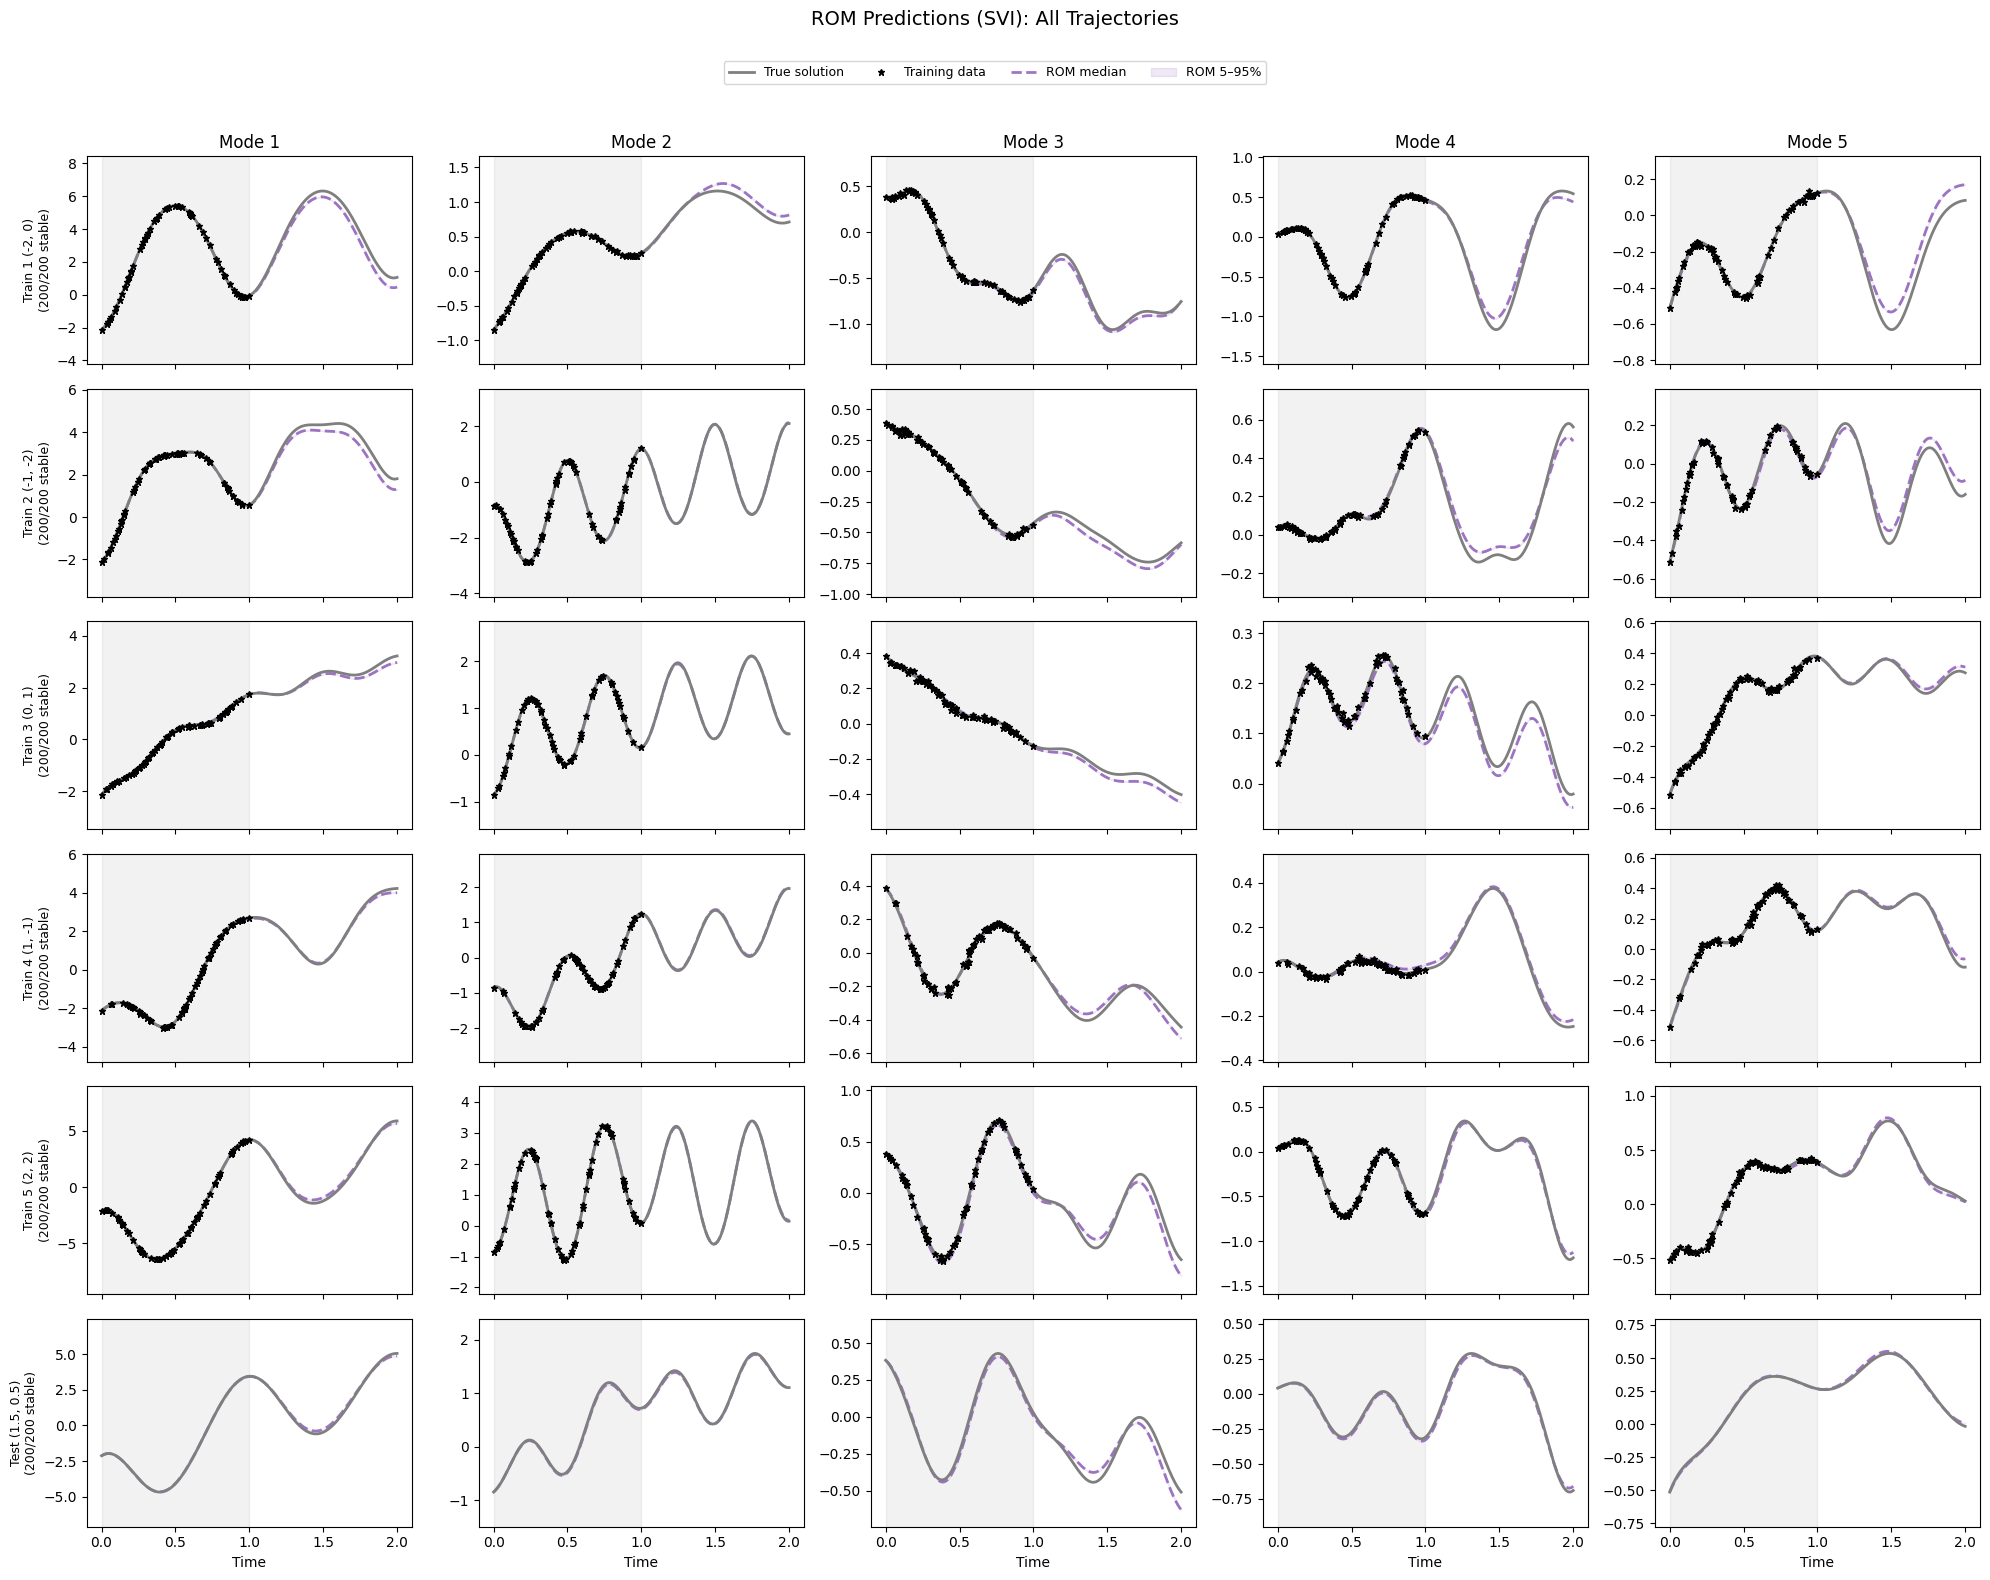

  Train 1 (-2, 0): mean err = 7.9220%, stable = 200
  Train 2 (-1, -2): mean err = 7.8128%, stable = 200
  Train 3 (0, 1): mean err = 4.1545%, stable = 200
  Train 4 (1, -1): mean err = 2.7915%, stable = 200
  Train 5 (2, 2): mean err = 3.7075%, stable = 200
  Test (1.5, 0.5): mean err = 3.3818%, stable = 200


In [125]:
# === SVI Results ===
_plot_t0 = time.time()
if RUN_SVI:
    svi_Os, svi_all_solves, svi_all_errors, svi_fig_rom = _evaluate_and_plot(
        svi_result.samples, "SVI"
    )
total_plot_time += time.time() - _plot_t0


In [126]:
# Run MCMC (optional, more expensive)
if RUN_MCMC:
    # Initialize from SVI if requested and available
    init_values = None
    if USE_SVI_FOR_MCMC_INIT and RUN_SVI and 'svi_O_init' in dir() and svi_O_init is not None:
        init_values = {"O": svi_O_init}
        print(f"Initializing MCMC from SVI result (shape: {svi_O_init.shape})")
    else:
        print("MCMC will find its own starting point via NUTS adaptation")

    # Build shifted model or reuse SVI model
    if USE_SHIFTED_PRIOR_FOR_MCMC and RUN_SVI and 'svi_Os' in dir():
        mcmc_model = build_bayesian_opinf_model(
            prior_operator=jnp.zeros_like(prior_operator),
            rom=rom,
            Ls_means=all_Ls,
            Vs_means=all_Vs,
            time_domain_sampled=all_time_sampled,
            snapshots=all_snapshots_comp,
            Xs_means=all_Xs_means,
            Ns_means=all_Ns,
            inputs_eval=all_inputs_eval,
            data_scaler=data_scaler if USE_SCALED_DATA else None,
            reparam="shifted",
            svi_O_mean=svi_Os.mean(axis=0),
            svi_O_std=jnp.ones_like(svi_Os.mean(axis=0))*GAMMA3
        )
        print("Built shifted model: prior re-centered on SVI posterior")
    else:
        mcmc_model = bayesian_opinf_model
        print("Using original model for MCMC")

    mcmc_result = run_mcmc(
        model=mcmc_model,
        rng_key=jax.random.PRNGKey(1),
        time_eval=time_eval,
        init_values=init_values,
        gamma=GAMMA3 if GAMMA3 else GAMMA,
        gamma2=GAMMA4 if GAMMA4 else GAMMA2,
        num_warmup=150,
        num_samples=200,
        num_chains=2,
        verbose=VERBOSE
    )
    samples = mcmc_result.samples

Initializing MCMC from SVI result (shape: (5, 33))
Built shifted model: prior re-centered on SVI posterior
Running MCMC (2 chains, 150 warmup, 200 samples)...


sample: 100%|██████████| 350/350 [00:51<00:00,  6.78it/s, 511 steps of size 2.68e-02. acc. prob=0.88] 

✅ MCMC complete! 400 samples collected.


### 5b. MCMC Results

[MCMC] Operator samples: 200, Stable solves (1st IC): 199


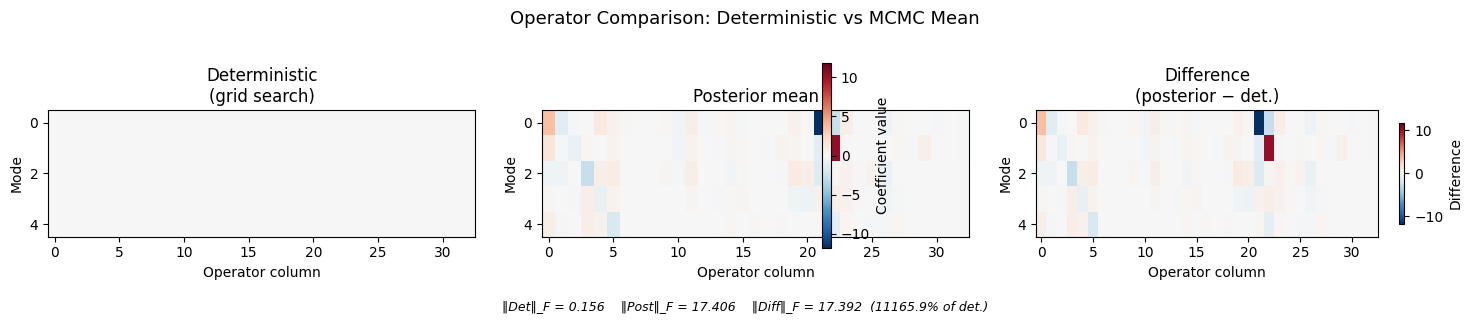

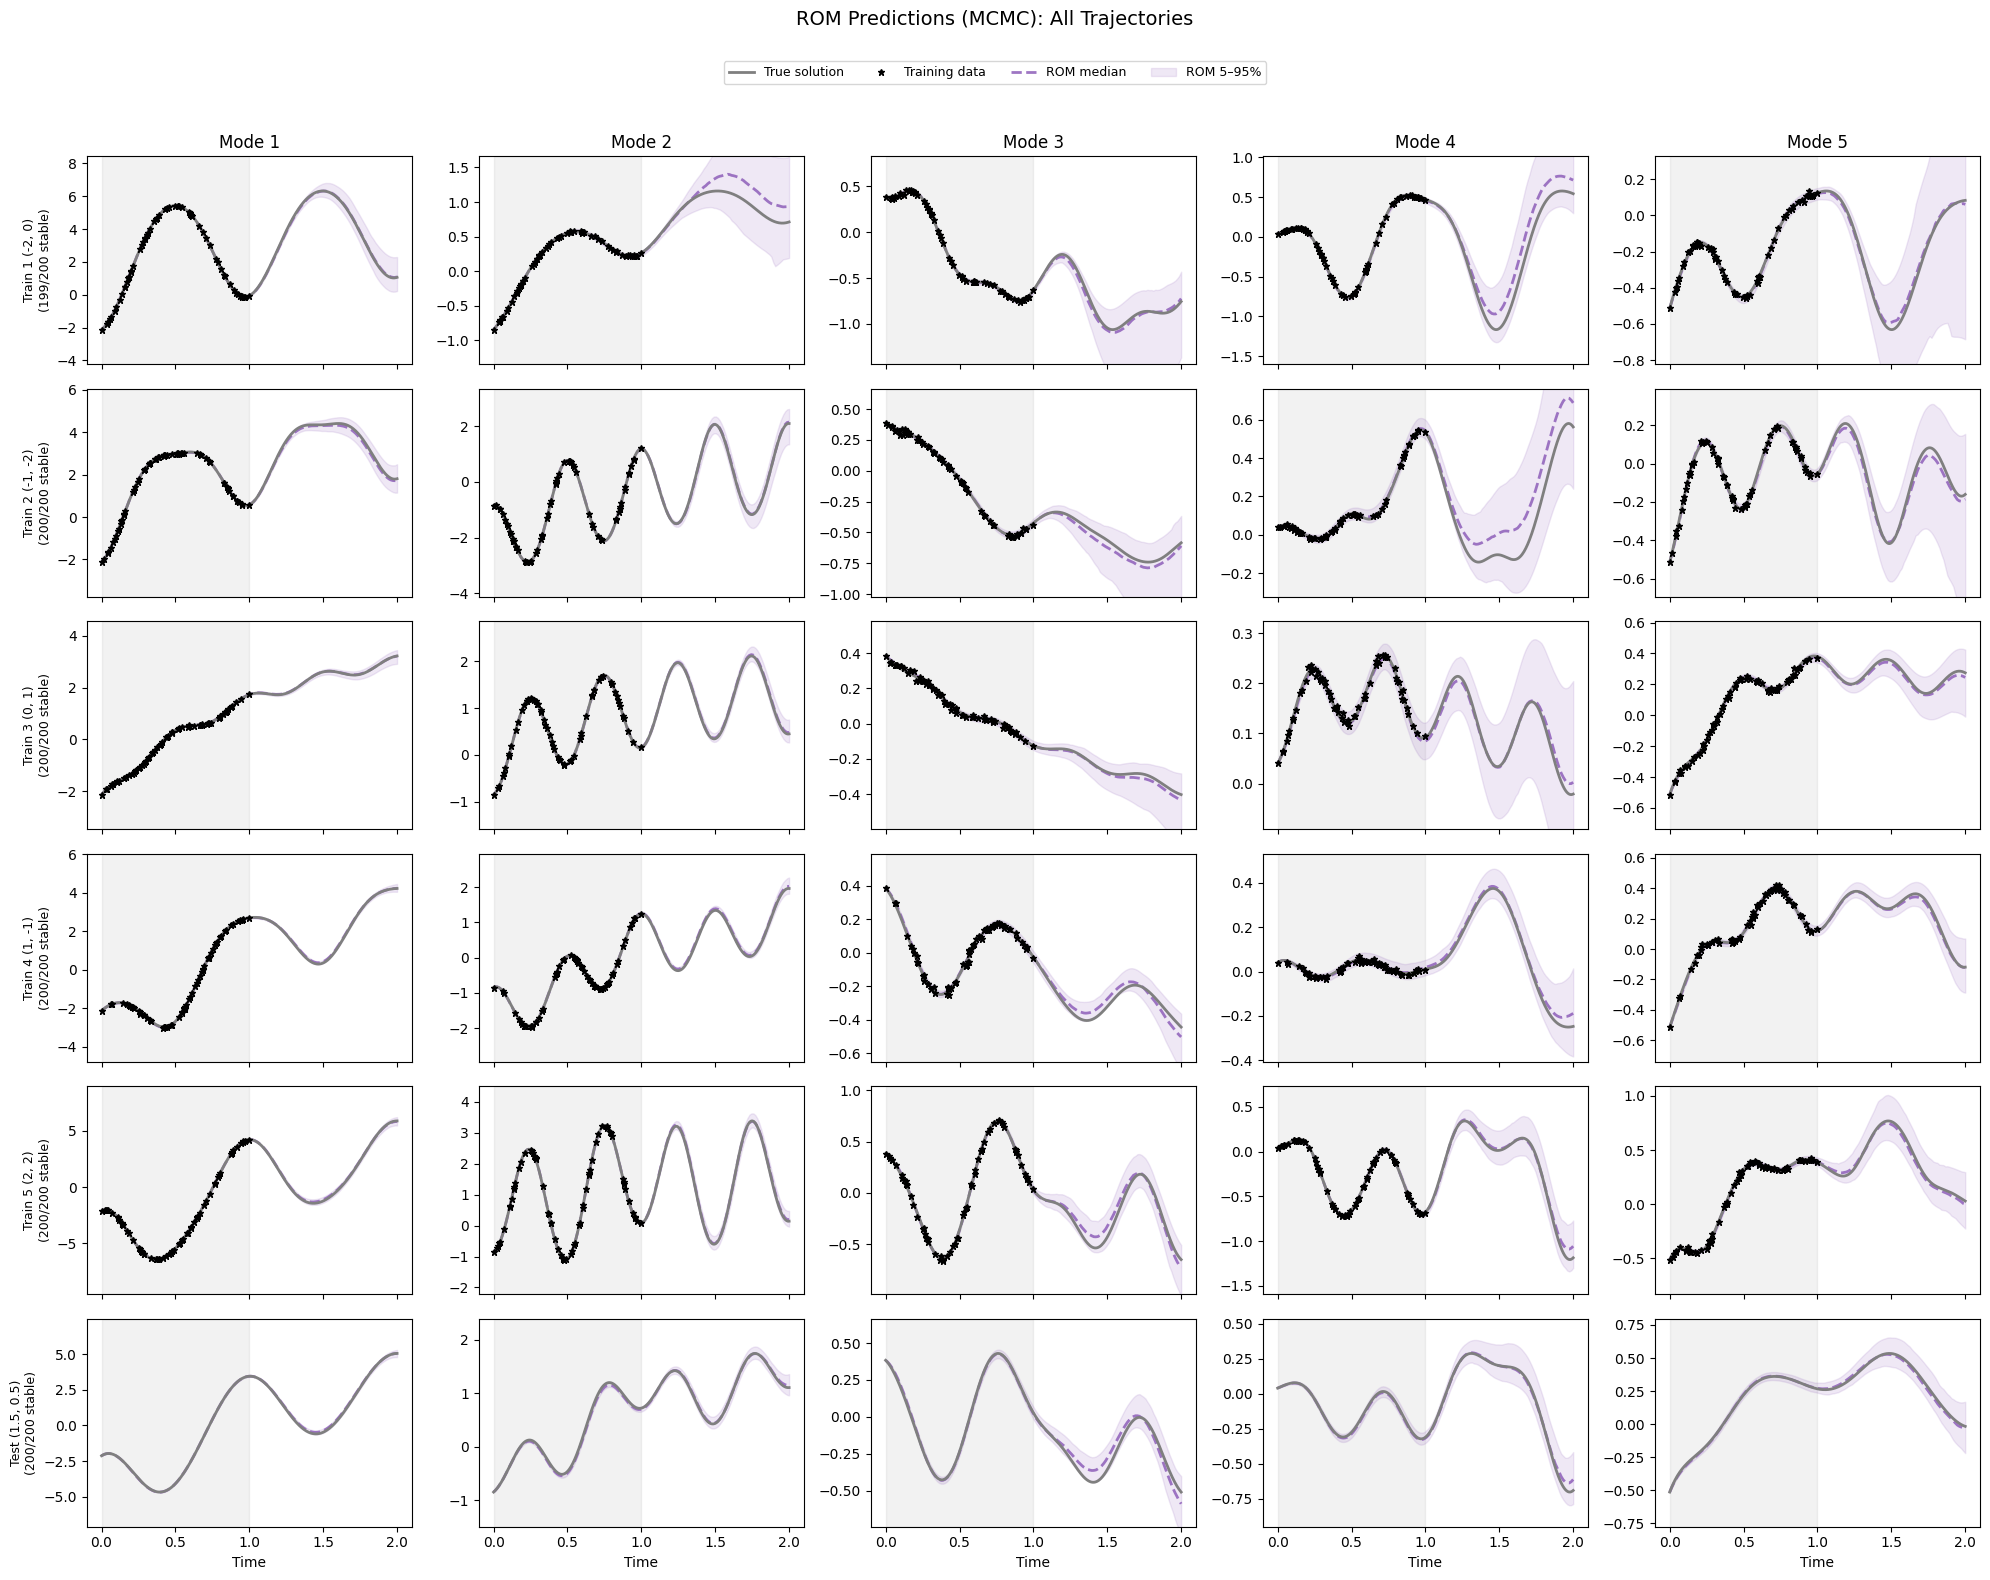

  Train 1 (-2, 0): mean err = 11.5475%, stable = 199
  Train 2 (-1, -2): mean err = 8.8320%, stable = 200
  Train 3 (0, 1): mean err = 5.1859%, stable = 200
  Train 4 (1, -1): mean err = 4.0285%, stable = 200
  Train 5 (2, 2): mean err = 4.8138%, stable = 200
  Test (1.5, 0.5): mean err = 4.2840%, stable = 200


In [127]:
# === MCMC Results ===
_plot_t0 = time.time()
if RUN_MCMC:
    mcmc_Os, mcmc_all_solves, mcmc_all_errors, mcmc_fig_rom = _evaluate_and_plot(
        mcmc_result.samples, "MCMC"
    )
    if SAVE_PAPER_FIGURES:
        save_paper_figure(mcmc_fig_rom, f"heat_{PAPER_SCENARIO}_fb", PAPER_FIGURES_DIR)
total_plot_time += time.time() - _plot_t0


In [128]:
# Algorithm timing summary
end_time = time.time()
algo_time = end_time - start_time - total_plot_time

print(f"Total wall time: {end_time - start_time:.1f}s")
print(f"Plot time excluded: {total_plot_time:.1f}s")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

Total wall time: 140.7s
Plot time excluded: 10.6s
Algorithm runtime: 130.1s (2.2min)


## 6. Results and Visualization

In [129]:
# Check sample keys (debug)
print("Sample keys:", list(samples.keys())[:5], "...")
print()

# Generate ROM predictions on the full PREDICTION domain
# This tests both interpolation (within training span) and extrapolation (beyond)
Os, Xs, rom_solves = generate_rom_predictions(
    samples=samples,
    rom=rom,
    snapshots_compressed=snapshots_comp_first,
    time_eval=time_domain_eval_prediction,
    num_modes=NUM_MODES,
    num_pulls=200,
    input_func=first_input_func,
    data_scaler=data_scaler if USE_SCALED_DATA else None
,
    ivp_method=IVP_METHOD,
)

print(f"Collected {len(Os)} operator samples")
print(f"Stable ROM solves: {len(rom_solves)} (on prediction domain [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}])")

Sample keys: ['O', 'O_standardized', 'X0_0', 'X0_1', 'X0_2'] ...

Collected 200 operator samples
Stable ROM solves: 199 (on prediction domain [0, 2.0])


In [130]:
# Operator posterior summary
O_mean = Os.mean(axis=0)
O_std = Os.std(axis=0)

print("Prior operator (first row):")
print(prior_operator[0, :5])
print("\nPosterior mean (first row):")
print(O_mean[0, :5])
print("\nPosterior std (first row):")
print(O_std[0, :5])

Prior operator (first row):
[-0.00485614  0.00159057  0.0002778   0.00172948 -0.00292816]

Posterior mean (first row):
[ 3.519118   -1.2355074  -0.21112004  0.07265367  1.165443  ]

Posterior std (first row):
[0.1696169  0.01917659 0.04831206 0.4392988  0.6145597 ]


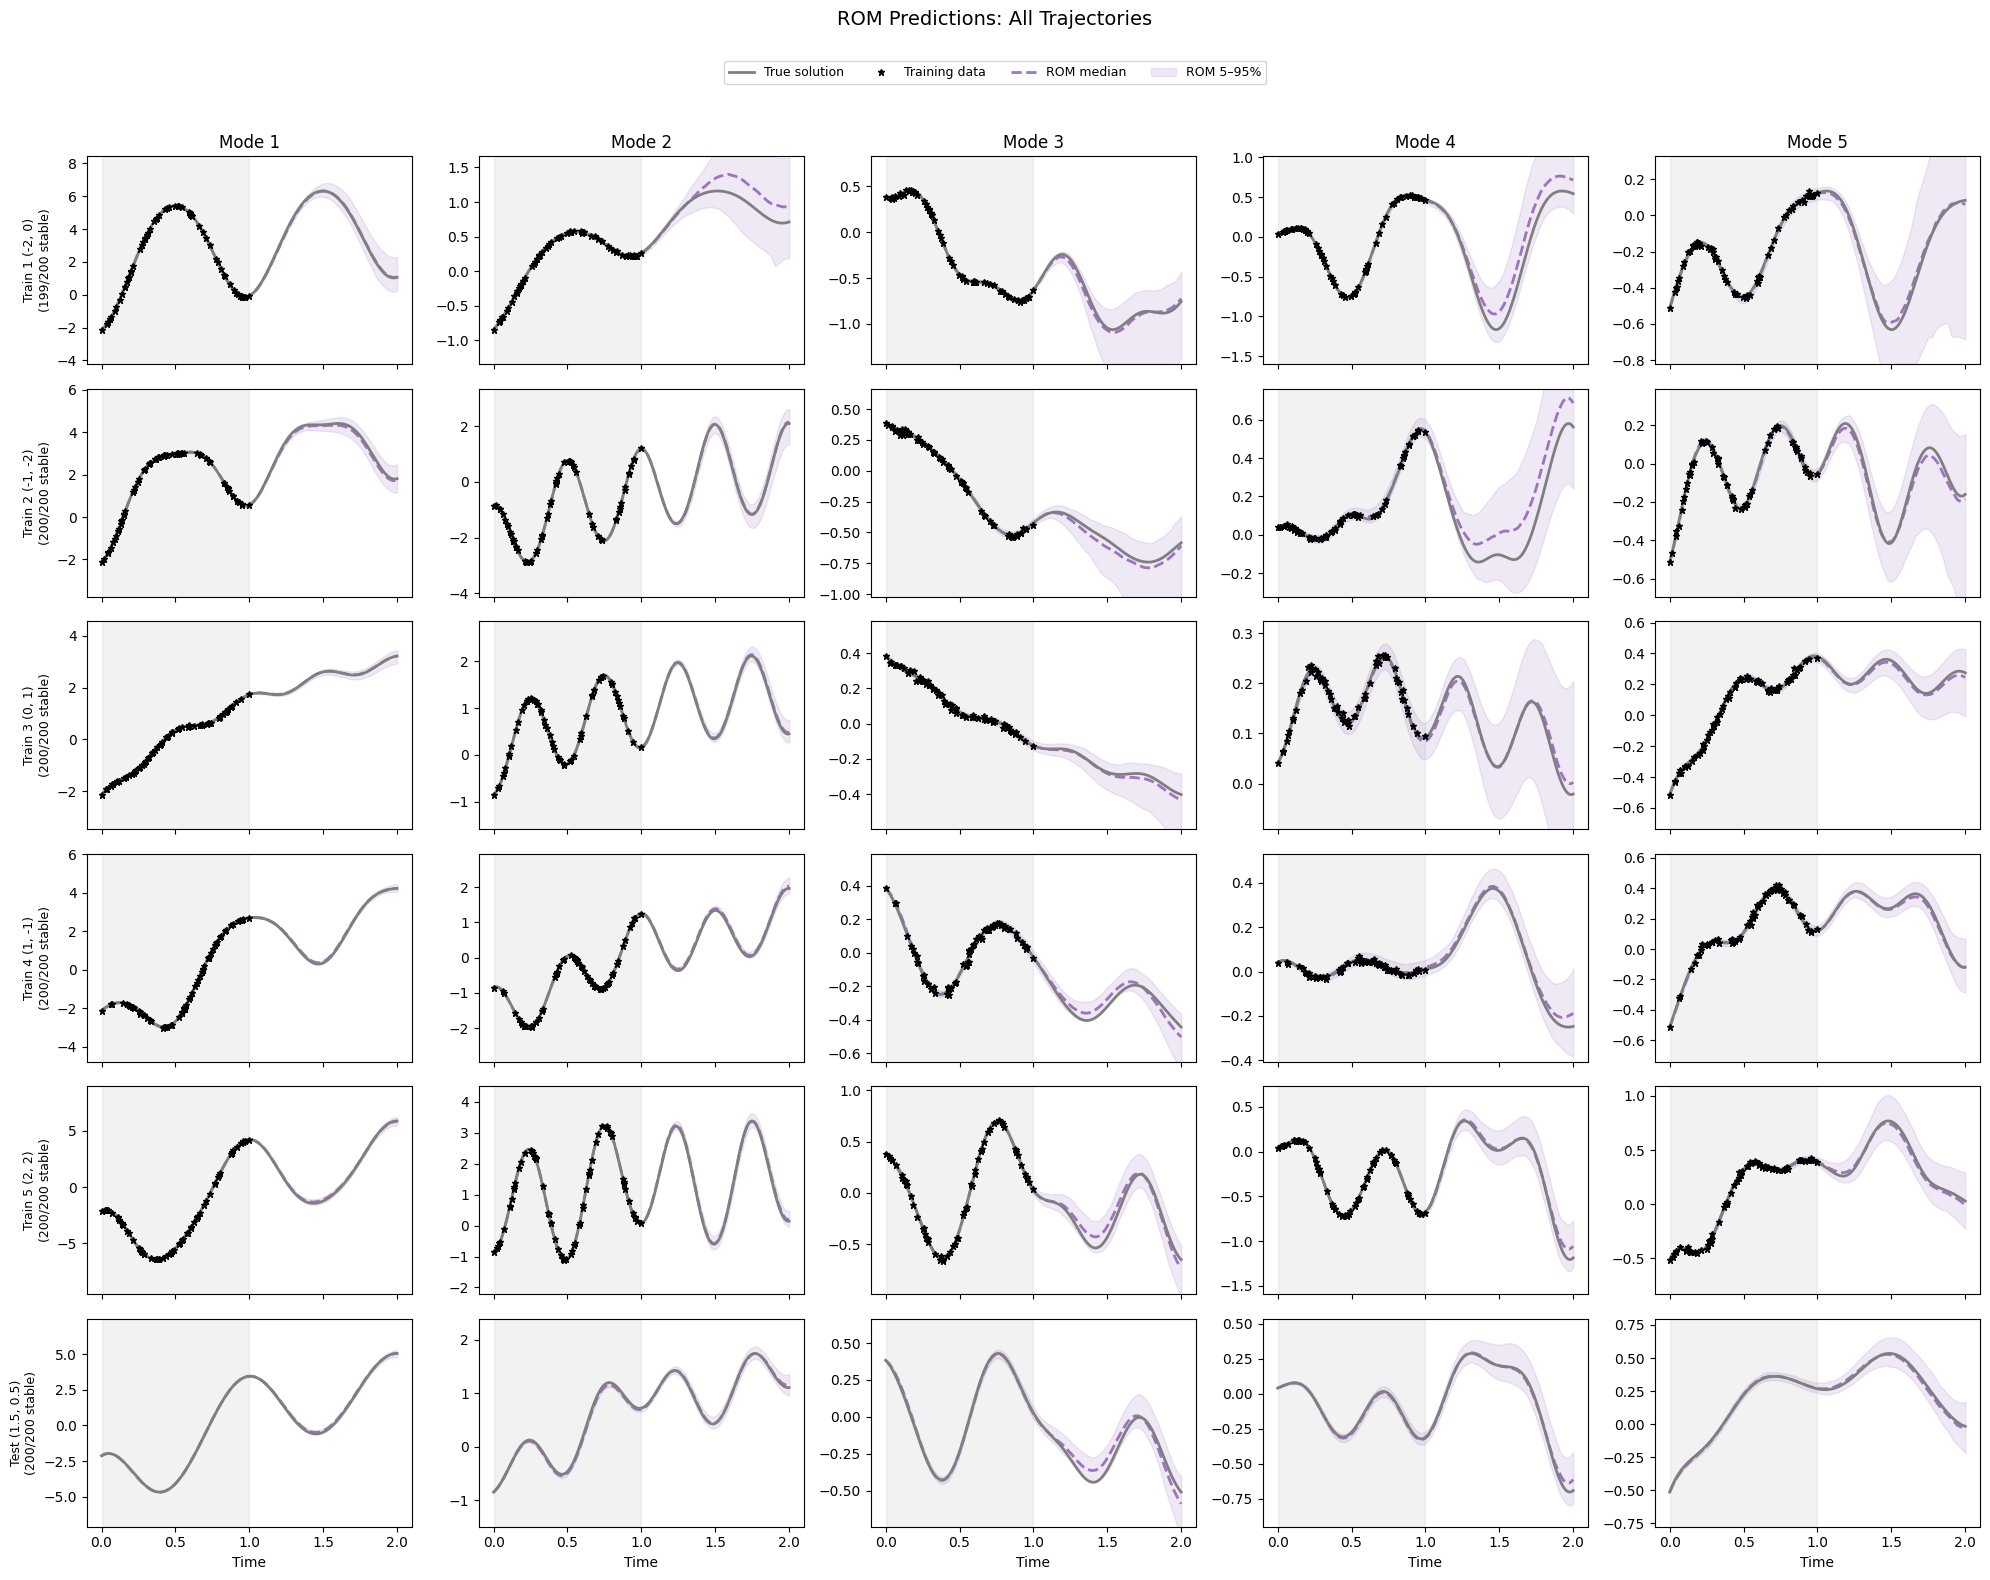

In [131]:
_plot_t0 = time.time()
# All-trajectory ROM predictions using HeatPlotter
import importlib
import heat_plotter
importlib.reload(heat_plotter)
from heat_plotter import HeatPlotter, compute_trajectory_errors

plotter = HeatPlotter(
    numPODmodes=NUM_MODES,
    time_domain_training=all_time_sampled[0],
    time_domain_prediction=time_domain_full,
    time_domain_eval_training=time_domain_eval_training,
    time_domain_eval_prediction=time_domain_eval_prediction,
    snapshots_training=snapshots_comp_first,
    snapshots_prediction=snapshots_comp_first,
)

# Build trajectory dicts for all training ICs + test IC
trajectories = []
for ic_idx in range(NUM_TRAIN_ICS):
    snap_start = ic_idx * NUM_SAMPLES
    snap_end = (ic_idx + 1) * NUM_SAMPLES
    snapshots_ic = all_snapshots_comp_raw[ic_idx]
    true_ic = all_true_compressed[ic_idx]
    trajectories.append({
        'q0': snapshots_ic[:, 0],
        'input_func': input_func_factory(train_params[ic_idx]),
        'snapshots': snapshots_ic,
        'time_snapshots': all_time_sampled[ic_idx],
        'true_compressed': true_ic,
        'time_true': time_domain_full,
        'label': f'Train {ic_idx+1} {train_params[ic_idx]}',
    })

# Add test trajectory (no training data)
trajectories.append({
    'q0': snapshots_test_compressed[:, 0],
    'input_func': input_func_factory(test_params),
    'snapshots': None,
    'time_snapshots': None,
    'true_compressed': snapshots_test_compressed,
    'time_true': time_domain_full,
    'label': f'Test {test_params}',
})

# Multi-trajectory plot (rows = trajectories, cols = modes)
# ROM evaluates on the full prediction domain — extrapolates beyond training span
fig, axes, all_rom_solves = plotter.multi_trajectory_plot(
    operator_samples=Os,
    rom=rom,
    trajectories=trajectories,
    time_eval=time_domain_eval_prediction,
    max_num_samples=200,
    training_span=TRAINING_SPAN,
)
plt.show()
total_plot_time += time.time() - _plot_t0

In [132]:
# Compute errors for all trajectories (training + test)
print("=" * 60)
print("TRAJECTORY ERRORS (vs projected FOM truth)")
print("=" * 60)

all_errors = {}
for i, (traj, rom_solves_i) in enumerate(zip(trajectories, all_rom_solves)):
    label = traj.get('label', f'Trajectory {i+1}')
    if len(rom_solves_i) > 0 and traj.get('true_compressed') is not None:
        errors = compute_trajectory_errors(
            rom_solves_i, traj['true_compressed'],
            time_domain_eval_prediction, traj['time_true'], NUM_MODES,
        )
        all_errors[label] = errors
        print(f"\n{label}:")
        print(f"  Mean relative error: {np.mean(errors):.4%}")
        print(f"  Std relative error:  {np.std(errors):.4%}")
        print(f"  Stable solves: {len(rom_solves_i)}")
    else:
        print(f"\n{label}: No stable ROM solutions")

TRAJECTORY ERRORS (vs projected FOM truth)

Train 1 (-2, 0):
  Mean relative error: 11.5475%
  Std relative error:  7.1006%
  Stable solves: 199

Train 2 (-1, -2):
  Mean relative error: 8.8320%
  Std relative error:  4.4148%
  Stable solves: 200

Train 3 (0, 1):
  Mean relative error: 5.1859%
  Std relative error:  2.9125%
  Stable solves: 200

Train 4 (1, -1):
  Mean relative error: 4.0285%
  Std relative error:  2.2998%
  Stable solves: 200

Train 5 (2, 2):
  Mean relative error: 4.8138%
  Std relative error:  3.1785%
  Stable solves: 200

Test (1.5, 0.5):
  Mean relative error: 4.2840%
  Std relative error:  1.7479%
  Stable solves: 200


## 7. Test Trajectory Generalization

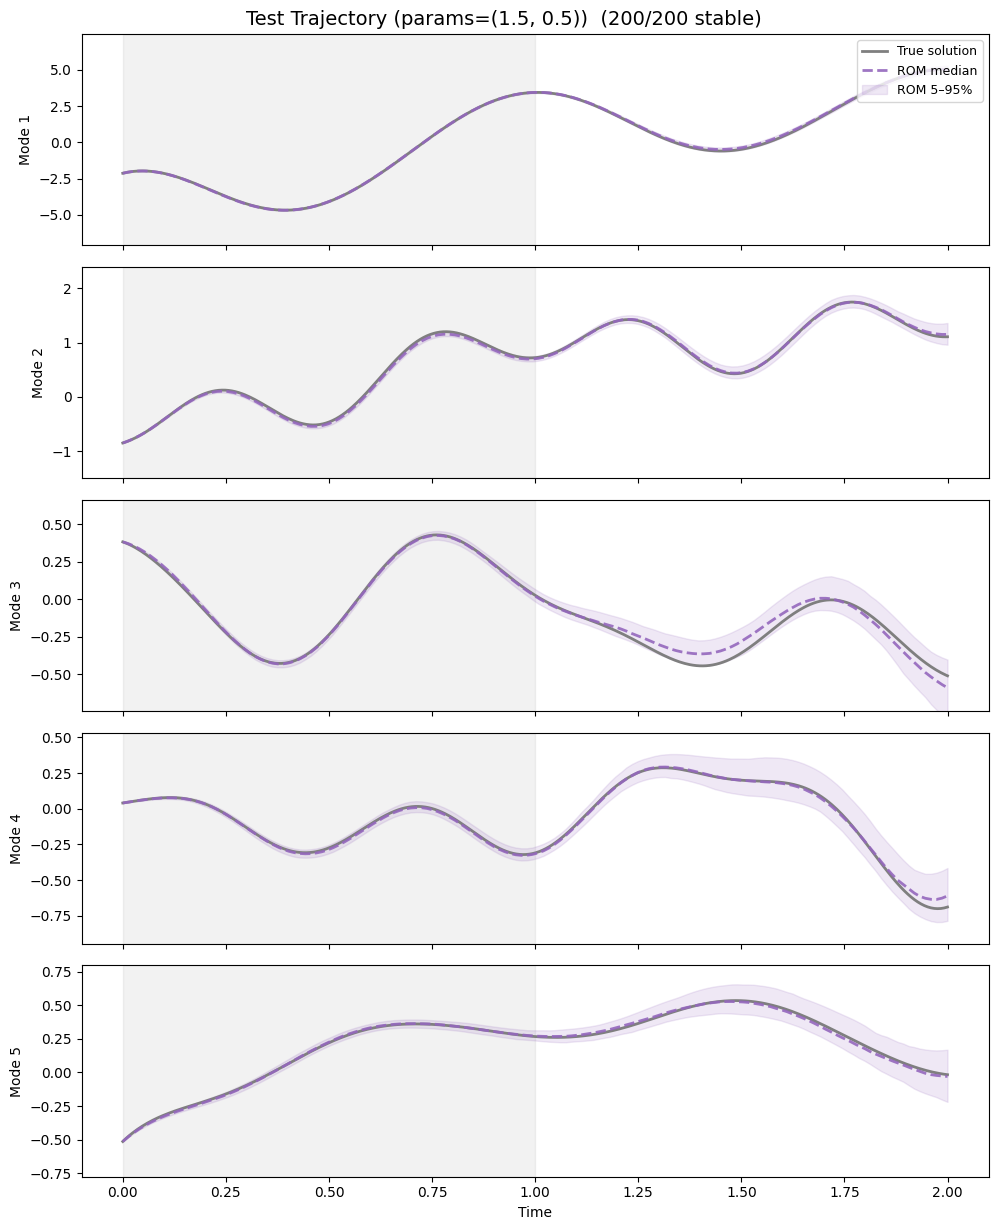


Test Trajectory Errors:
  Mean relative error: 4.2840%
  Std relative error:  1.7479%
  Stable solves: 200/200


In [133]:
# Detailed view: Test trajectory (single-column, euler style)
fig, axes, test_rom_solves = plotter.single_trajectory_plot(
    operator_samples=Os,
    rom=rom,
    q0=snapshots_test_compressed[:, 0],
    time_eval=time_domain_eval_prediction,
    input_func=input_func_factory(test_params),
    true_compressed=snapshots_test_compressed,
    time_true=time_domain_full,
    title=f'Test Trajectory (params={test_params})',
    max_num_samples=200,
    training_span=TRAINING_SPAN,
)
plt.show()

# Test errors
if len(test_rom_solves) > 0:
    test_errors = compute_trajectory_errors(
        test_rom_solves, snapshots_test_compressed,
        time_domain_eval_prediction, time_domain_full, NUM_MODES,
    )
    print(f"\nTest Trajectory Errors:")
    print(f"  Mean relative error: {np.mean(test_errors):.4%}")
    print(f"  Std relative error:  {np.std(test_errors):.4%}")
    print(f"  Stable solves: {len(test_rom_solves)}/{min(len(Os), 200)}")

In [134]:
# Summary
print("=" * 50)
print("EXPERIMENT SUMMARY: Cubic Heat Equation")
print("=" * 50)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training ICs: {NUM_TRAIN_ICS}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Extrapolation: {PREDICTION_SPAN[1] - TRAINING_SPAN[1]:.2f}s beyond training")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"Prior regularization: {result.best_reg:.1e}")
print(f"Prior error: {result.best_error:.4%}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
print(f"\nTrajectory Results:")
for label, errors in all_errors.items():
    print(f"  {label}:")
    print(f"    Mean error: {np.mean(errors):.4%}")
    print(f"    Stable: {len(errors)}/{min(len(Os), 200)}")

EXPERIMENT SUMMARY: Cubic Heat Equation
Operators: cAHBN
Modes: 5
Training ICs: 5
Training span: [0, 1.0]
Prediction span: [0, 2.0]
Extrapolation: 1.00s beyond training
Scaling: disabled
Prior regularization: 2.2e+02
Prior error: 154.0935%
Gamma (operator): 1.0
Gamma2 (ODE): 1.0
Guide: AutoDelta

Trajectory Results:
  Train 1 (-2, 0):
    Mean error: 11.5475%
    Stable: 199/200
  Train 2 (-1, -2):
    Mean error: 8.8320%
    Stable: 200/200
  Train 3 (0, 1):
    Mean error: 5.1859%
    Stable: 200/200
  Train 4 (1, -1):
    Mean error: 4.0285%
    Stable: 200/200
  Train 5 (2, 2):
    Mean error: 4.8138%
    Stable: 200/200
  Test (1.5, 0.5):
    Mean error: 4.2840%
    Stable: 200/200


## 8. Bayesian Model Diagnostics

Run post-inference diagnostics to check for common pitfalls:
- **Posterior correlation** — highly correlated parameters suggest redundancy or non-identifiability
- **Effective sample size (ESS)** — low ESS means samples are highly autocorrelated
- **Prior-posterior overlap** — checks if data is actually informing the posterior
- **Trace plots** — visual check for mixing and stationarity
- **Divergences & R-hat** — MCMC-specific convergence checks (when applicable)

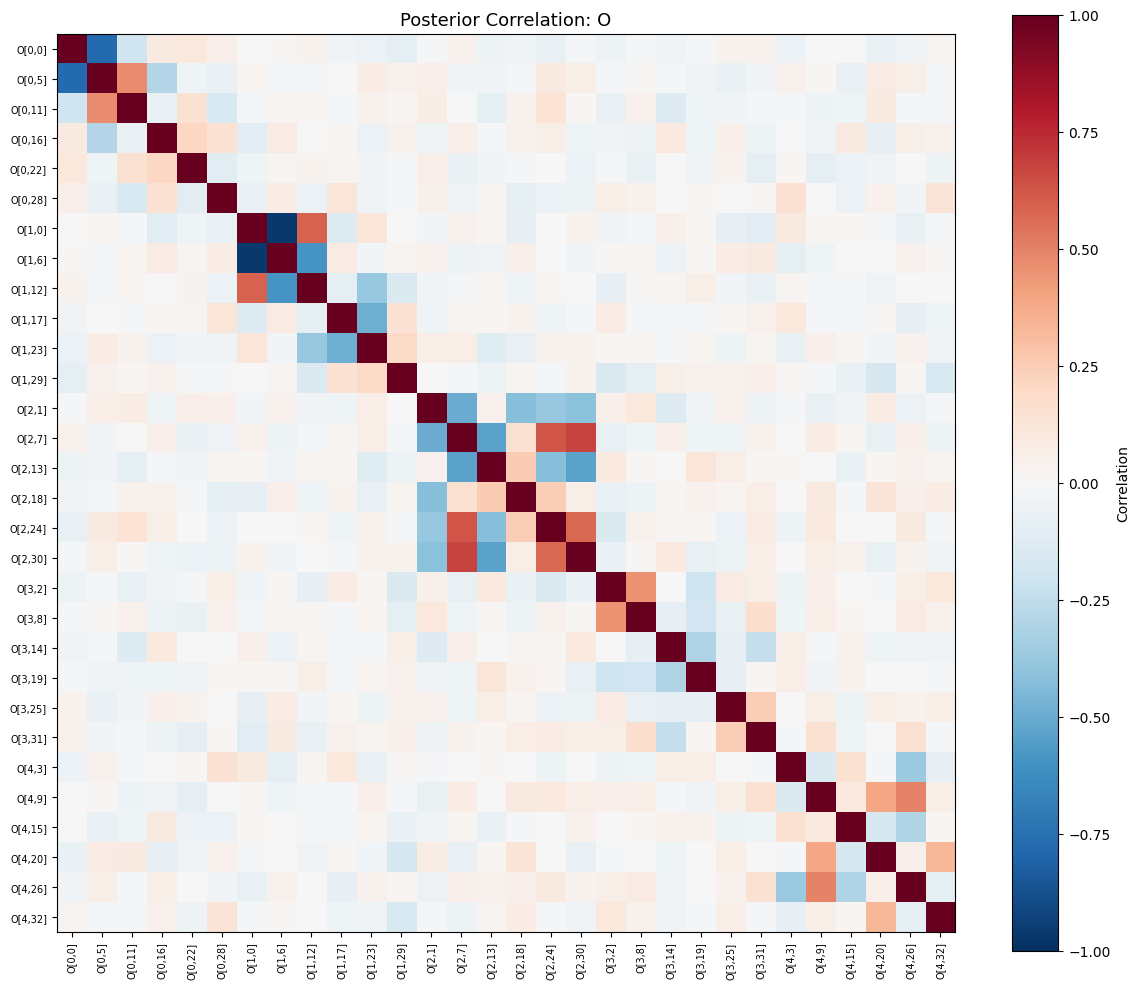

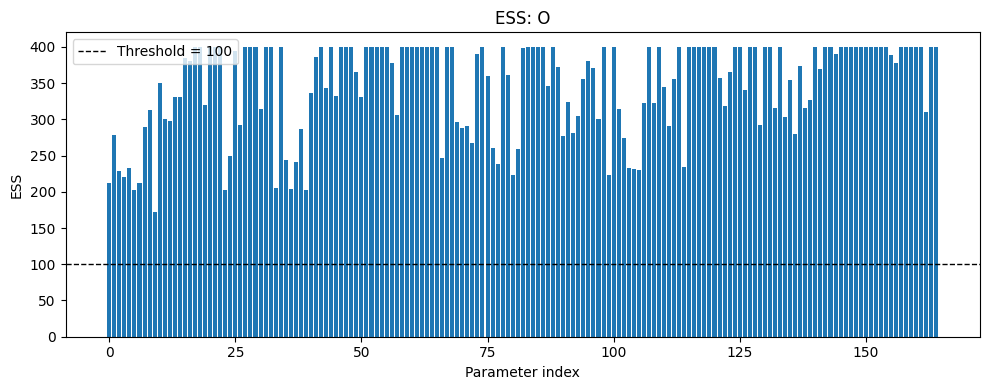

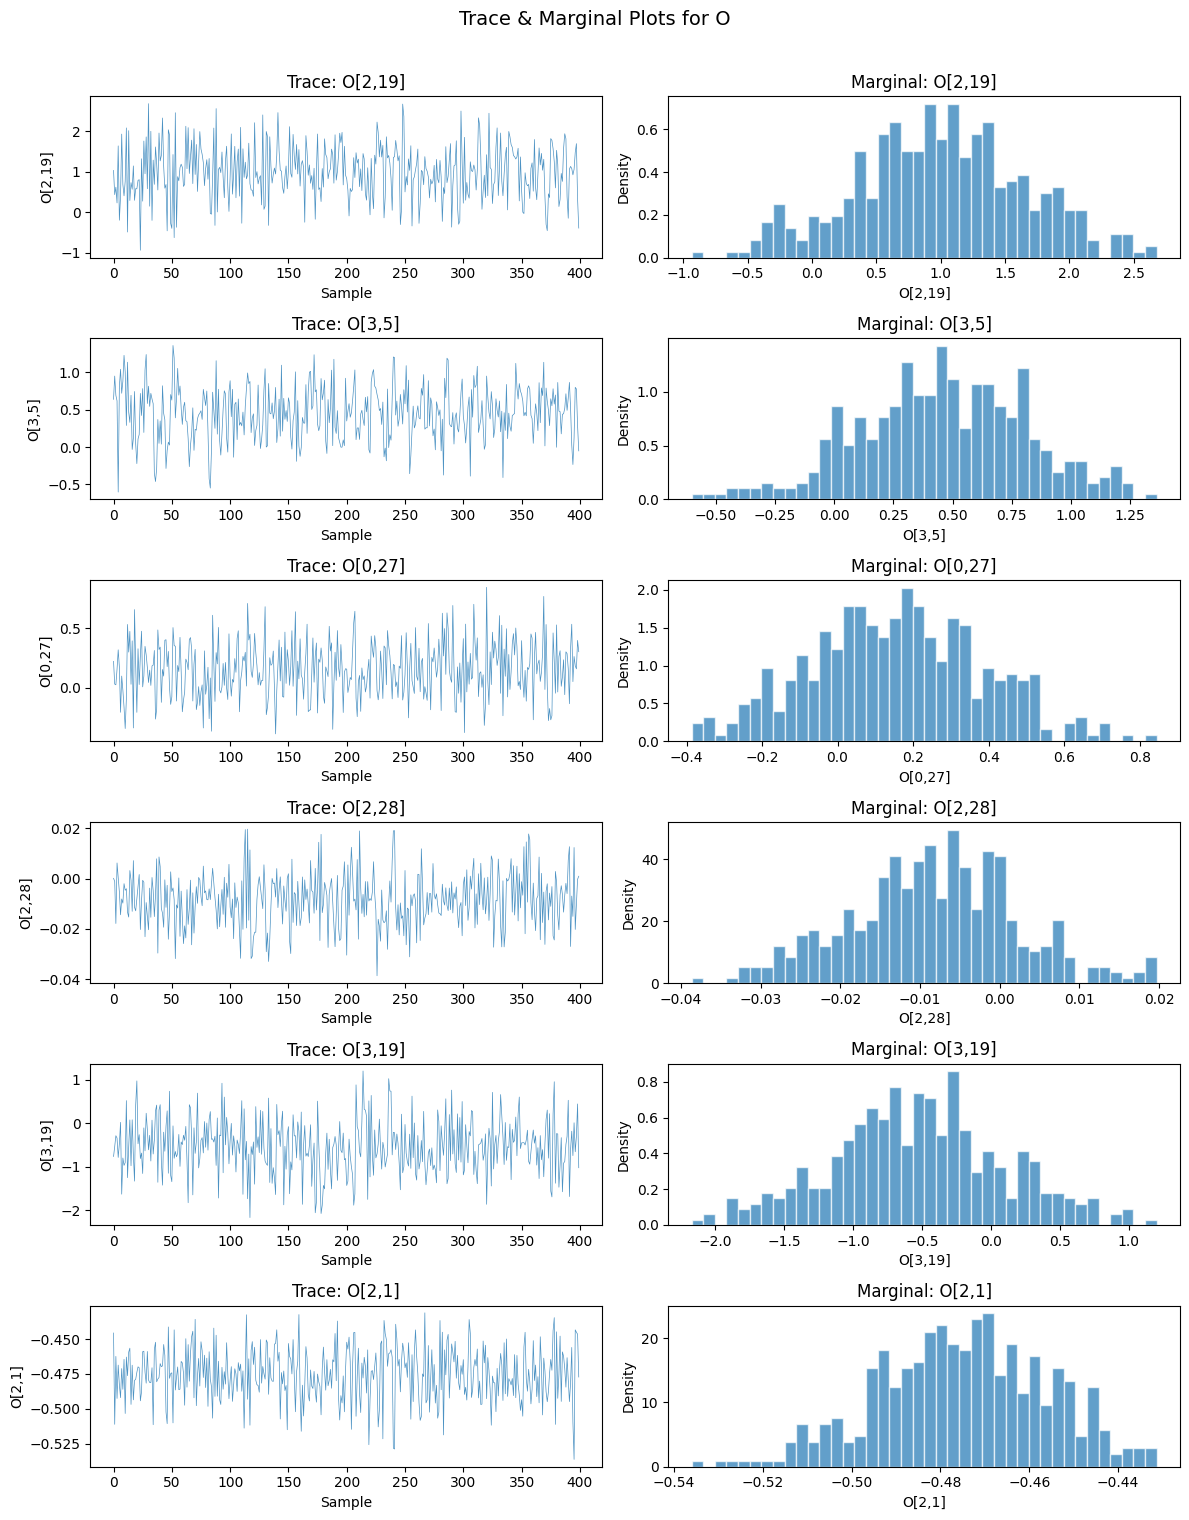

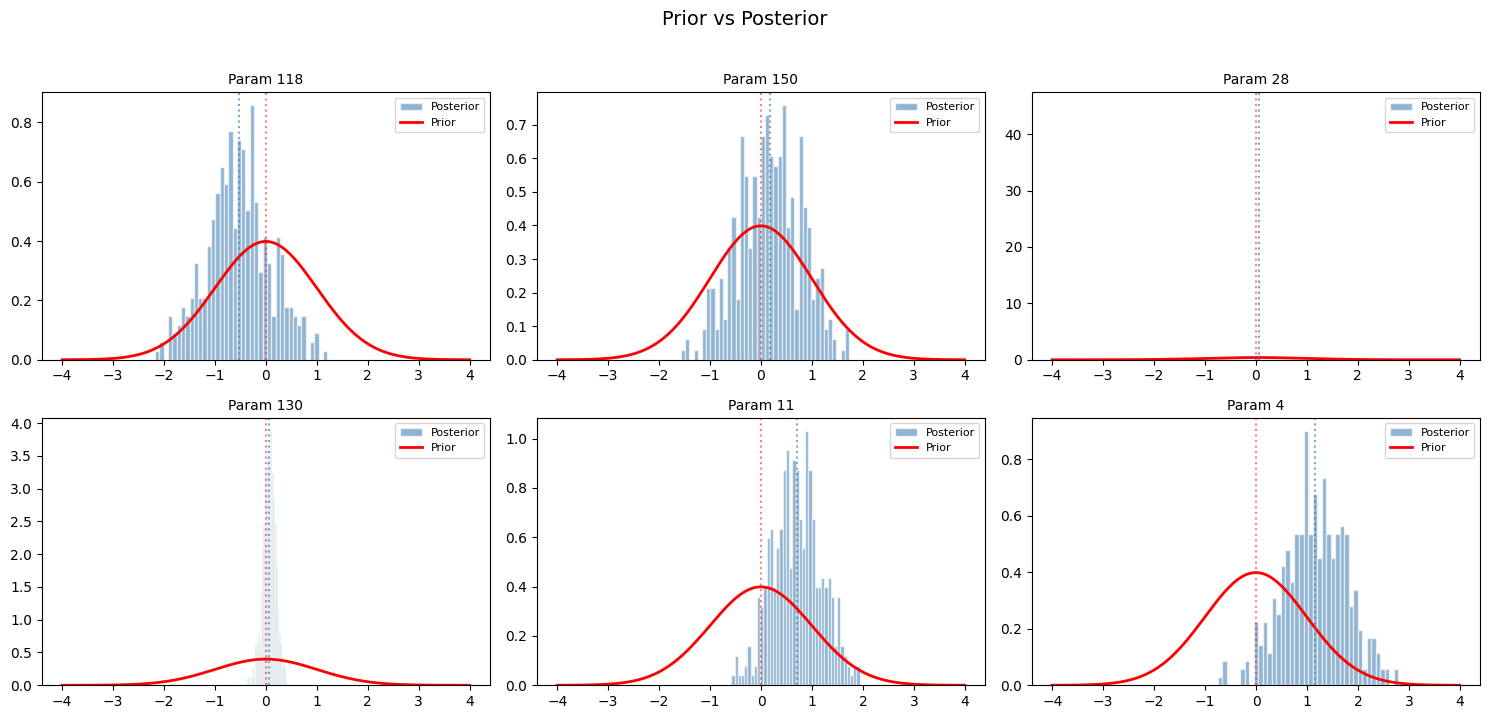

  BAYESIAN MODEL DIAGNOSTIC REPORT

--- Posterior Correlation ---
  20 highly correlated pairs (|r| > 0.9):
    O[3,0] <-> O[3,6]: r = -0.967
    O[1,0] <-> O[1,6]: r = -0.963
    O[4,0] <-> O[4,6]: r = -0.957
    O[2,0] <-> O[2,6]: r = -0.956
    O[0,0] <-> O[0,6]: r = -0.950
    O[3,10] <-> O[3,24]: r = +0.941
    O[3,0] <-> O[3,4]: r = -0.941
    O[0,0] <-> O[0,4]: r = -0.940
    O[1,0] <-> O[1,4]: r = -0.937
    O[4,0] <-> O[4,4]: r = -0.937
    ... and 10 more

--- Effective Sample Size (ESS) ---
  Min ESS:  172.2
  Mean ESS: 348.0
  Max ESS:  400.0

--- MCMC Divergences ---
  Divergent transitions: 0
  Fraction: 0.00%

--- Prior-Posterior Overlap ---
  O[4,7]: overlap = 8.19% [CHECK]
  O[1,21]: overlap = 7.77% [CHECK]
  O[1,17]: overlap = 31.68% [OK]
  O[2,6]: overlap = 8.94% [CHECK]
  O[0,2]: overlap = 11.62% [OK]

--- Summary Warnings ---
  1. Found 20 highly correlated parameter pairs (|r| > 0.9). Consider reparameterization.



In [135]:
# Run full diagnostic suite
# Pass mcmc_result if MCMC was used, otherwise None
diag_report = run_diagnostics(
    samples=samples,
    param_name="O",
    prior_mean=prior_operator,
    prior_std=GAMMA,
    mcmc_result=mcmc_result if RUN_MCMC else None,
    samples_by_chain=None,  # Set to per-chain sample dicts if using multi-chain MCMC
    correlation_threshold=0.9,
    ess_threshold=100,
    verbose=True,
    plot=True,
)